# Práctica 1

**Hugo, Fernando, Mario**

## 1. Comprensión de los datos y de los sensores

#### Clasificamos cada uno de los cuatro sensores ambientales como activo o pasivo, indicando la magnitud física que mide cada uno. 

Inicializamos librerías y mostramos el df

In [9]:
import pandas as pd 
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.covariance import EllipticEnvelope
import matplotlib.pyplot as plt

df = pd.read_csv("agri_sensors.csv")
df


,parcela_id,fecha,mes,region,tipo_cultivo,tamano_parcela,humedad_suelo,temperatura_C,temperatura_F,humedad_relativa,luminosidad,ph_suelo,riego_recomendado
0,P040,2025-06-09,2025-06,Este,vid,mediana,28.16,25.92,78.54,48.19,23168.1,6.5,medio
1,P029,2025-06-26,2025-06,Centro,maiz,grande,68.52,16.76,62.17,58.84,17529.5,6.5,bajo
2,P004,2025-06-12,2025-06,Centro,olivo,mediana,70.00,26.79,80.30,48.08,21869.0,6.5,bajo
3,P015,2025-06-20,2025-06,Centro,trigo,mediana,59.72,14.95,58.82,68.29,17132.4,6.5,bajo
4,P002,2025-06-29,2025-06,Sur,trigo,pequeña,NaN,20.69,69.23,54.08,19730.3,6.5,bajo
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,P035,2025-06-25,2025-06,Norte,olivo,pequeña,70.00,15.95,60.75,56.07,15811.8,6.5,bajo
1196,P037,2025-06-16,2025-06,Oeste,vid,pequeña,37.80,21.49,70.71,53.09,18897.7,6.5,medio
1197,P038,2025-06-21,2025-06,Sur,maiz,pequeña,22.53,16.54,61.79,61.57,18802.2,6.5,medio
1198,P029,2025-06-21,2025-06,Centro,maiz,grande,67.50,18.14,64.63,58.77,16750.3,6.5,bajo


Visualizamos información general del df.

In [3]:
df.describe()

,humedad_suelo,temperatura_C,temperatura_F,humedad_relativa,luminosidad,ph_suelo
count,1182.000000,1188.000000,1188.000000,1164.000000,1128.000000,1200.000000
mean,46.509687,22.017584,71.561818,55.054613,19986.012589,6.499417
std,18.854861,4.505871,8.132194,6.287580,3220.486209,0.008644
min,-14.030000,12.710000,54.910000,36.630000,11955.600000,6.400000
25%,33.145000,18.065000,64.440000,50.477500,17215.950000,6.500000
50%,46.390000,21.975000,71.250000,54.965000,19961.300000,6.500000
75%,62.580000,25.982500,78.700000,59.505000,22647.875000,6.500000
max,129.000000,32.010000,89.680000,71.590000,29408.600000,6.600000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   parcela_id         1200 non-null   str    
 1   fecha              1200 non-null   str    
 2   mes                1200 non-null   str    
 3   region             1200 non-null   str    
 4   tipo_cultivo       1200 non-null   str    
 5   tamano_parcela     1200 non-null   str    
 6   humedad_suelo      1182 non-null   float64
 7   temperatura_C      1188 non-null   float64
 8   temperatura_F      1188 non-null   float64
 9   humedad_relativa   1164 non-null   float64
 10  luminosidad        1128 non-null   float64
 11  ph_suelo           1200 non-null   float64
 12  riego_recomendado  1200 non-null   str    
dtypes: float64(6), str(7)
memory usage: 170.3 KB


In [6]:
pd.isnull(df).sum()

parcela_id            0
fecha                 0
mes                   0
region                0
tipo_cultivo          0
tamano_parcela        0
humedad_suelo        18
temperatura_C        12
temperatura_F        12
humedad_relativa     36
luminosidad          72
ph_suelo              0
riego_recomendado     0
dtype: int64

Con este analisis inicial vemos que hay variables con celdas nulas por lo que ahora debemos pensar que podemos hacer con ellas. Hay dos posibilidades o imputar valores o eliminar directamente las celdas. Para ello veremos las características de las columnas y con ello decidiremos. 

In [10]:

# Porcentaje de valores faltantes por columna
print((df.isna().mean() * 100).round(2))




parcela_id           0.0
fecha                0.0
mes                  0.0
region               0.0
tipo_cultivo         0.0
tamano_parcela       0.0
humedad_suelo        1.5
temperatura_C        1.0
temperatura_F        1.0
humedad_relativa     3.0
luminosidad          6.0
ph_suelo             0.0
riego_recomendado    0.0
dtype: float64


Podemos ver que las temperaturas estan relacionadas por la relacion de Celsius y Fahrenheit por lo que antes de imputar valores comprobaremos si en la misma fila aparece el valor de al menos una variable y asi poder sacar el otro sin necesidad de elimina o imputar el valor.

In [12]:
 #Guardamos las medias originales antes de imputar
media_C = df['temperatura_C'].mean()
media_F = df['temperatura_F'].mean()

# Si falta Celsius y tenemos Fahrenheit, convertimos F -> C
mask_C = df['temperatura_C'].isna() & df['temperatura_F'].notna()

df.loc[mask_C, 'temperatura_C'] = (
    df.loc[mask_C, 'temperatura_F'] - 32
) * 5 / 9

# Si falta Fahrenheit y tenemos Celsius, convertimos C -> F
mask_F = df['temperatura_F'].isna() & df['temperatura_C'].notna()

df.loc[mask_F, 'temperatura_F'] = (
    df.loc[mask_F, 'temperatura_C'] * 9 / 5
) + 32

# Si todavía quedan valores faltantes, usamos la media original
df['temperatura_C'] = df['temperatura_C'].fillna(media_C)
df['temperatura_F'] = df['temperatura_F'].fillna(media_F)

pd.isnull(df).sum()


parcela_id            0
fecha                 0
mes                   0
region                0
tipo_cultivo          0
tamano_parcela        0
humedad_suelo        18
temperatura_C         0
temperatura_F         0
humedad_relativa     36
luminosidad          72
ph_suelo              0
riego_recomendado     0
dtype: int64

In [20]:
# Diferencia respecto a la conversión esperada
diferencia = (
    df['temperatura_F']
    - (df['temperatura_C'] * 9/5 + 32)
).abs()

print(diferencia.describe())
print("Filas con diferencia superior a 1:",
      (diferencia > 1).sum())

count    1200.000000
mean        0.075757
std         0.061485
min         0.000000
25%         0.028000
50%         0.060000
75%         0.110500
max         0.340000
dtype: float64
Filas con diferencia superior a 1: 0


De esta manera comprobamos que las columnas son coherentes entre ellas ya que vemos que no hay una diferencia superior a 1F.

Para el resto de valores faltantes elegimos imputar la mediana ya que es un vaor central que no se va a ver muy afectado por los valores extremos o atípicos que pueden mostrar algunas columnas por alguna medición incorrecta.

In [14]:
columnas_mediana = [
    'humedad_suelo',
    'humedad_relativa',
    'luminosidad'
]

for col in columnas_mediana:
    df[col] = df[col].fillna(df[col].median())
    
pd.isnull(df).sum()



parcela_id           0
fecha                0
mes                  0
region               0
tipo_cultivo         0
tamano_parcela       0
humedad_suelo        0
temperatura_C        0
temperatura_F        0
humedad_relativa     0
luminosidad          0
ph_suelo             0
riego_recomendado    0
dtype: int64

Ahora combrobaremos los tipos y categorías mas afondo. Además comprobaremos los valores extremos o sospechosos.

In [15]:
# Tipos de datos
print(df.dtypes)

# Valores diferentes de las variables categóricas
for col in ['region', 'tipo_cultivo',
            'tamano_parcela', 'riego_recomendado']:
    print(f"\n{col}:")
    print(df[col].value_counts())

parcela_id               str
fecha                    str
mes                      str
region                   str
tipo_cultivo             str
tamano_parcela           str
humedad_suelo        float64
temperatura_C        float64
temperatura_F        float64
humedad_relativa     float64
luminosidad          float64
ph_suelo             float64
riego_recomendado        str
dtype: object

region:
region
Este      330
Sur       270
Centro    240
Norte     240
Oeste     120
Name: count, dtype: int64

tipo_cultivo:
tipo_cultivo
maiz     420
olivo    300
vid      270
trigo    210
Name: count, dtype: int64

tamano_parcela:
tamano_parcela
pequeña    510
mediana    450
grande     240
Name: count, dtype: int64

riego_recomendado:
riego_recomendado
bajo     746
medio    355
alto      99
Name: count, dtype: int64


In [17]:
#Pasamos la columna fecha a un tipo de date real para poder trabajar con ello en algun futuro.
df['fecha'] = pd.to_datetime(df['fecha'])

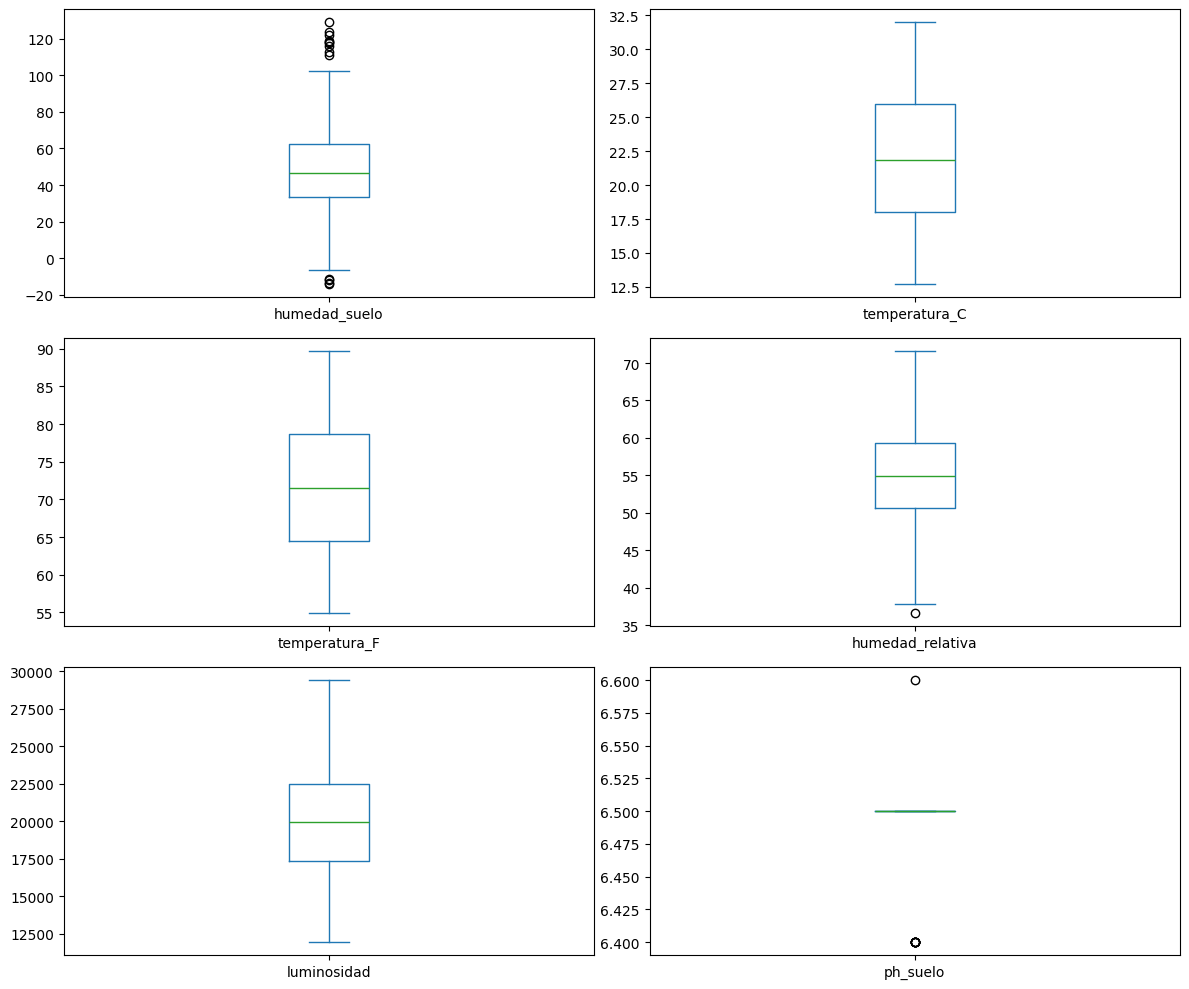

In [26]:

columnas_numericas = [
    'humedad_suelo',
    'temperatura_C',
    'temperatura_F',
    'humedad_relativa',
    'luminosidad',
    'ph_suelo'
]

df[columnas_numericas].plot(
    kind='box',
    subplots=True,
    layout=(3, 2),
    figsize=(12, 10),
    sharex=False,
    sharey=False
)

plt.tight_layout()
plt.show()


Vemos que humedad_suelo contiene varios valores atípicos por lo que estudiaremos su caso:

In [29]:
Q1 = df['humedad_suelo'].quantile(0.25)
Q3 = df['humedad_suelo'].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[
    (df['humedad_suelo'] < limite_inferior) |
    (df['humedad_suelo'] > limite_superior)
]

print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)
print("Número de valores atípicos:", len(outliers))

Límite inferior: -10.162499999999994
Límite superior: 105.97749999999999
Número de valores atípicos: 13


In [31]:
#Visualizamos exactamente las filas con esos valores atipicos.
print(
    outliers[
        ['humedad_suelo', 'parcela_id', 'fecha',
         'region', 'tipo_cultivo']
    ].sort_values('humedad_suelo')
)

      humedad_suelo parcela_id      fecha  region tipo_cultivo
374          -14.03       P019 2025-06-22    Este          vid
822          -13.67       P023 2025-06-05    Este         maiz
530          -11.69       P039 2025-06-17   Oeste         maiz
634          -11.07       P025 2025-06-13    Este         maiz
963          110.95       P015 2025-06-02  Centro        trigo
323          112.90       P020 2025-06-30   Norte          vid
398          115.83       P023 2025-06-19    Este         maiz
95           117.61       P023 2025-06-11    Este         maiz
324          118.37       P038 2025-06-10     Sur         maiz
310          118.89       P008 2025-06-02     Sur        trigo
1029         121.83       P021 2025-06-09     Sur         maiz
924          123.32       P013 2025-06-15    Este        olivo
1155         129.00       P026 2025-06-27  Centro         maiz


Al relaizar el estudio y no tener mas contexto sobre como se realizan las mediaciones no podemos determinar si son errores de medicion o si en realidad son correctas las mediciones. En este caso, cabe documentar el hallazgo y ponerse en contrcto con las fincas para saber como manejar estos datos o si las medidas son porcentajes, en cuyo caso habria que eliminar los valores inferiores a 0 y superiores a 100.

Para ir finaliznado con el preprocesado miraremos a ver si hay alguna fila duplicada.

In [21]:
# Filas completamente duplicadas
print("Filas duplicadas:", df.duplicated().sum())

# Combinaciones repetidas de parcela y fecha
print(
    "Combinaciones parcela-fecha duplicadas:",
    df.duplicated(subset=['parcela_id', 'fecha']).sum()
)

Filas duplicadas: 0
Combinaciones parcela-fecha duplicadas: 0


Como no hay filas duplicadas para finalizar nuestro preprocesamiento empezaremos a estudiar la correlación entre las distintas variables numericas

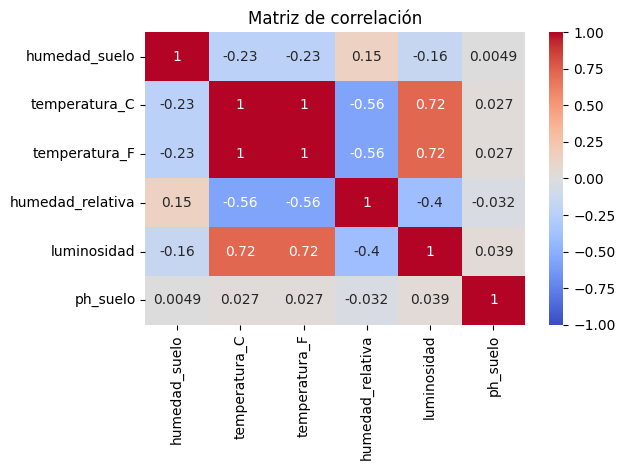

In [28]:

import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionamos únicamente las columnas numéricas
columnas_numericas = df.select_dtypes(include='number')

# Calculamos la matriz de correlación
correlacion = columnas_numericas.corr()

# Representamos la matriz
sns.heatmap(
    correlacion,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()


Una vez realizado el preprocesamiento del dataset y ya lo tenemos limpio y comprendido podemos trabajar con el con mas normalidad y soltura

## Ejercicios

### Ejercicio 1

El conjunto de datos contiene cuatro magnitudes ambientales principales: humedad del suelo, temperatura, humedad relativa y luminosidad. Estas representan, respectivamente, el contenido de humedad del suelo, la temperatura ambiental, la proporción de vapor de agua presente en el aire respecto a su saturación y la iluminancia.

De forma orientativa, los cuatro sensores se consideran pasivos, suponiendo que detectan las magnitudes presentes en el entorno sin emitir energía de sondeo para realizar la medición. No obstante, el enunciado no especifica los modelos ni los principios físicos de funcionamiento, por lo que esta clasificación deberá confirmarse mediante la documentación técnica de los dispositivos.

| Sensor ambiental | Magnitud física que mide | Unidad habitual | Clasificación orientativa |
|---|---|---|---|
| Humedad del suelo | Contenido de humedad del suelo | % según el enunciado | Pasivo, bajo el supuesto indicado |
| Temperatura | Temperatura ambiental | °C | Pasivo, bajo el supuesto indicado |
| Humedad relativa | Proporción de vapor de agua presente en el aire respecto a la cantidad de saturación a esa temperatura | % | Pasivo, bajo el supuesto indicado |
| Luminosidad | Iluminancia o luz incidente por unidad de superficie | lux | Pasivo, bajo el supuesto indicado |

Por otro lado, podemos ver que hay atributos redundantes, como es el caso de la temperatura para la cual tenemos dos mediciones distintas las cuales proporcionan la misma información.

A continuación se muestra una tabla con la manera de proceder con las variables:

| Atributo | ¿Qué haría? | Justificación |
|---|---|---|
| `parcela_id` | Mantener | Es un identificador, no una medida ambiental. Puede servir para identificar parcelas y agrupar sus mediciones. |
| `fecha` | Mantener | Puede aportar información temporal sobre las mediciones. |
| `mes` | Eliminar | Es una variable derivada de `fecha` y, en este dataset, todas las observaciones corresponden a junio de 2025. |
| `region` | Mantener | Puede aportar información geográfica relevante para las necesidades de riego. |
| `tipo_cultivo` | Mantener | Los distintos cultivos pueden tener diferentes necesidades de agua. |
| `tamano_parcela` | Mantener | Describe una característica de la parcela que podría resultar útil. |
| `humedad_suelo` | Mantener | Es una variable ambiental potencialmente muy relevante para recomendar el riego. |
| `temperatura_C` | Mantener | Representa la temperatura en una unidad habitual. |
| `temperatura_F` | Eliminar | Es redundante con `temperatura_C`, puesto que ambas expresan la misma magnitud mediante una conversión matemática. |
| `humedad_relativa` | Mantener | Describe la humedad del aire, que es diferente de la humedad del suelo. |
| `luminosidad` | Mantener | Puede ayudar a caracterizar las condiciones ambientales. |
| `ph_suelo` | Mantener inicialmente | Aunque presenta muy poca variabilidad en los datos observados, conviene comprobar si esa característica es real antes de eliminarlo. |
| `riego_recomendado` | Mantener como objetivo | Es la variable que se pretende predecir en el futuro modelo. |

Procederemos a la eliminación de las variables

In [32]:
df1 = df.drop(columns = ["mes","temperatura_F"])
df1.head()

,parcela_id,fecha,region,tipo_cultivo,tamano_parcela,humedad_suelo,temperatura_C,humedad_relativa,luminosidad,ph_suelo,riego_recomendado
0,P040,2025-06-09,Este,vid,mediana,28.16,25.92,48.19,23168.1,6.5,medio
1,P029,2025-06-26,Centro,maiz,grande,68.52,16.76,58.84,17529.5,6.5,bajo
2,P004,2025-06-12,Centro,olivo,mediana,70.00,26.79,48.08,21869.0,6.5,bajo
3,P015,2025-06-20,Centro,trigo,mediana,59.72,14.95,68.29,17132.4,6.5,bajo
4,P002,2025-06-29,Sur,trigo,pequeña,46.39,20.69,54.08,19730.3,6.5,bajo


Se decide eliminar el atributo mes porque se deriva de la columna fecha y todas las observaciones corresponden a junio de 2025, por lo que no aporta información diferenciadora en este conjunto de datos.

También se elimina temperatura_F, ya que representa la misma magnitud física que temperatura_C, expresada en otra unidad mediante una conversión matemática. Además ya hemos visto que la correlación entre ambas es de 1. Se conserva temperatura_C para evitar duplicidad de información.

### Ejercicio 2

Para este ejercicio ya tenemos la respuesta en todo el preprocesamiento que hemos hecho previo al ejercicio. Como un peuqueño resumen los principales cambios que hemos hecho ha sido imputrar los valores faltantes por la mediana debido a la existencia de valores atipicos y ser menos sensible a ellos que la propia media. Para las columnas de Temperatura_C y Temperatura_F al estar relacionadas hemos decidido en primer lugar, comprobar que en la fila que hubiera un valor faltante que el valor correspondiente en la otra columna relacionada tuviera el valor y realizar la correspondiente transformación. En segundo lugar, si no existe ninguno de los dos valores imputamos también el valor.

Para la detección de outliers utilizamos el rango intercuartílico (IQR) y además los representamos en diagramas de cajas. Donde mas valores atípicos hay y los tratamos es en Humedad_suelo donde debido a la falta de información no llegamos a descartar datos o imputarlos debido a la posible perdida de información que puede producir si llegasen a ser datos legítimos.

### Ejercicio 3

En primer lugar lo que haremos será normalizar las variables numéricas.

In [36]:
from sklearn.preprocessing import MinMaxScaler
columnas_numericas1 = df1.select_dtypes(include="number")


# Normalizamos las variables
scaler = MinMaxScaler()
datos_normalizados = scaler.fit_transform(columnas_numericas1)

df_normalizado = pd.DataFrame(
    datos_normalizados,
    columns=columnas_numericas1.columns,
    index=df.index
)

# Calculamos la varianza de cada atributo normalizado
varianzas = df_normalizado.var().sort_values()

print(varianzas)

ph_suelo            0.001868
humedad_suelo       0.017117
humedad_relativa    0.031375
luminosidad         0.032004
temperatura_C       0.054625
dtype: float64


Se ha aplicado un método de selección de atributos basado en la varianza. Para comparar las variables numéricas en una escala común, se han normalizado previamente sus valores mediante MinMaxScaler, transformándolos al intervalo [0, 1].

Los resultados muestran que ph_suelo presenta la menor varianza (0,001868), lo que indica una dispersión reducida de sus valores. Por otro lado, temperatura_C presenta la mayor varianza (0,054625) entre los atributos numéricos analizados.

Aunque ph_suelo presenta una variabilidad reducida, se decide conservarla en esta fase, ya que una varianza baja no implica necesariamente que el atributo carezca de utilidad para predecir la recomendación de riego. 

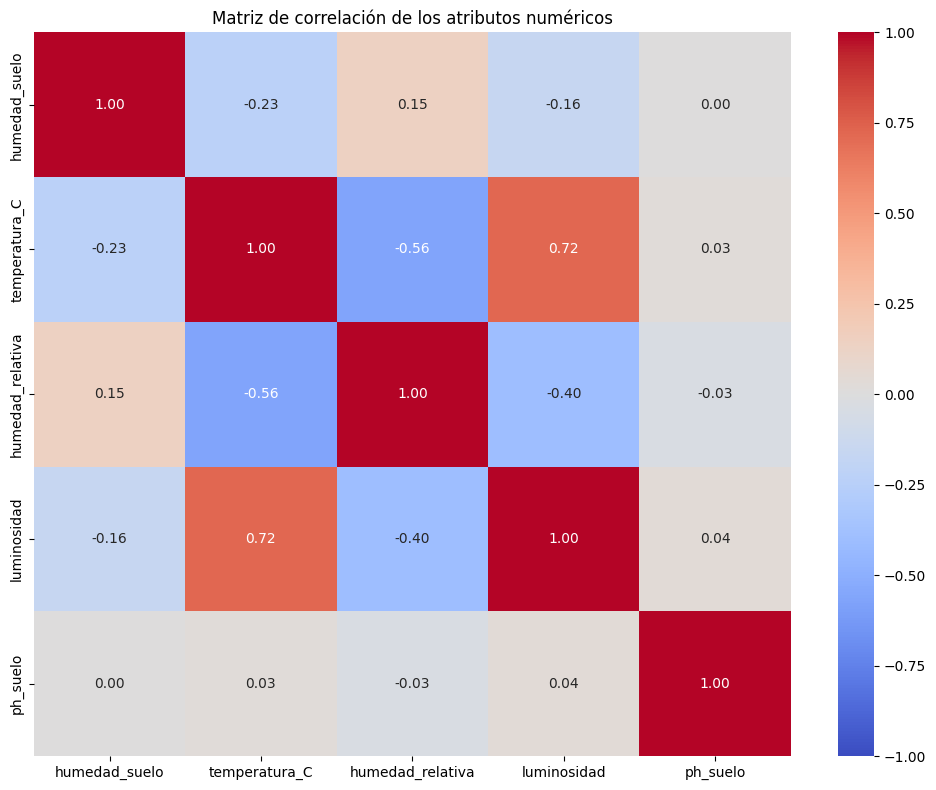

In [37]:
columnas_numericas1 = df_normalizado.select_dtypes(include="number")

# Calculamos la matriz de correlación
correlacion1 = columnas_numericas1.corr()

# Representamos la matriz mediante un mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlacion1,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f"
)
plt.title("Matriz de correlación de los atributos numéricos")
plt.tight_layout()
plt.show()

Como se ha observado anteriormente durante el preprocesamiento, las variables temperatura_C y temperatura_F presentaban una correlación de 1, lo que indica una relación lineal positiva perfecta entre ambas en el conjunto de datos analizado. Esto significa que proporcionan información redundante, ya que representan la misma magnitud física en diferentes unidades. Por este motivo, se decidió eliminar temperatura_F y conservar temperatura_C, evitando así la redundancia de atributos.

### Ejercicio 4

One_hot_encoding

In [38]:
# Creamos una copia para aplicar las transformaciones
df_transformado = df1.copy()

# Codificamos tipo_cultivo mediante One-Hot Encoding
df_transformado = pd.get_dummies(
    df_transformado,
    columns=["tipo_cultivo"],
    dtype=int
)

# Comprobamos las primeras filas y las columnas creadas
display(df_transformado.head())

print("Columnas del conjunto transformado:")
print(df_transformado.columns.tolist())


,parcela_id,fecha,region,tamano_parcela,humedad_suelo,temperatura_C,humedad_relativa,luminosidad,ph_suelo,riego_recomendado,tipo_cultivo_maiz,tipo_cultivo_olivo,tipo_cultivo_trigo,tipo_cultivo_vid
0,P040,2025-06-09,Este,mediana,28.16,25.92,48.19,23168.1,6.5,medio,0,0,0,1
1,P029,2025-06-26,Centro,grande,68.52,16.76,58.84,17529.5,6.5,bajo,1,0,0,0
2,P004,2025-06-12,Centro,mediana,70.00,26.79,48.08,21869.0,6.5,bajo,0,1,0,0
3,P015,2025-06-20,Centro,mediana,59.72,14.95,68.29,17132.4,6.5,bajo,0,0,1,0
4,P002,2025-06-29,Sur,pequeña,46.39,20.69,54.08,19730.3,6.5,bajo,0,0,1,0


Columnas del conjunto transformado:
['parcela_id', 'fecha', 'region', 'tamano_parcela', 'humedad_suelo', 'temperatura_C', 'humedad_relativa', 'luminosidad', 'ph_suelo', 'riego_recomendado', 'tipo_cultivo_maiz', 'tipo_cultivo_olivo', 'tipo_cultivo_trigo', 'tipo_cultivo_vid']


Ahora tenemos en lugar de una coloumna y el nombre del cultivo, tenemos el nombre del cultivo como  columna y un uno si se trata de ese cultivo o un cero si no. Con esto haremos que podamos entrenar el modelo de ML.

In [ ]:
# Codificar el tamaño de la parcela a 0 , 1 , 2 correspondiente a pequeño, mediano, grande.
# Se trata de una codificación ordinal porque los dtos siguen un orden natural.


# Definimos explícitamente el orden natural de las categorías
orden_tamanos = {
    "pequeña": 0,
    "mediana": 1,
    "grande": 2
}

# Aplicamos la codificación ordinal
df_transformado["tamano_parcela"] = (
    df_transformado["tamano_parcela"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(orden_tamanos)
)

# Comprobamos el resultado
print(df_transformado["tamano_parcela"].value_counts(dropna=False))
display(df_transformado[["tamano_parcela"]].head())


tamano_parcela
0    510
1    450
2    240
Name: count, dtype: int64


,tamano_parcela
0,1
1,2
2,1
3,1
4,0


Estandarizamos

In [40]:

from sklearn.preprocessing import StandardScaler

# Seleccionamos las variables numéricas de los sensores
columnas_numericas = [
    "humedad_suelo",
    "temperatura_C",
    "humedad_relativa",
    "luminosidad",
    "ph_suelo"
]

# Creamos una copia del conjunto de datos
df_estandarizado = df_transformado.copy()

# Aplicamos la estandarización
scaler = StandardScaler()

df_estandarizado[columnas_numericas] = scaler.fit_transform(
    df_estandarizado[columnas_numericas]
)

# Comprobamos el resultado
display(df_estandarizado[columnas_numericas].head())

print("\nMedias después de estandarizar:")
print(df_estandarizado[columnas_numericas].mean().round(3))

print("\nDesviaciones estándar después de estandarizar:")
print(df_estandarizado[columnas_numericas].std(ddof=0).round(3))


,humedad_suelo,temperatura_C,humedad_relativa,luminosidad,ph_suelo
0,-0.980908,0.870616,-1.108567,1.020049,0.067511
1,1.176803,-1.160921,0.611976,-0.786617,0.067511
2,1.255926,1.063568,-1.126338,0.603804,0.067511
3,0.706341,-1.562349,2.138655,-0.913852,0.067511
4,-0.006303,-0.289312,-0.157018,-0.081458,0.067511



Medias después de estandarizar:
humedad_suelo       0.0
temperatura_C      -0.0
humedad_relativa    0.0
luminosidad        -0.0
ph_suelo            0.0
dtype: float64

Desviaciones estándar después de estandarizar:
humedad_suelo       1.0
temperatura_C       1.0
humedad_relativa    1.0
luminosidad         1.0
ph_suelo            1.0
dtype: float64


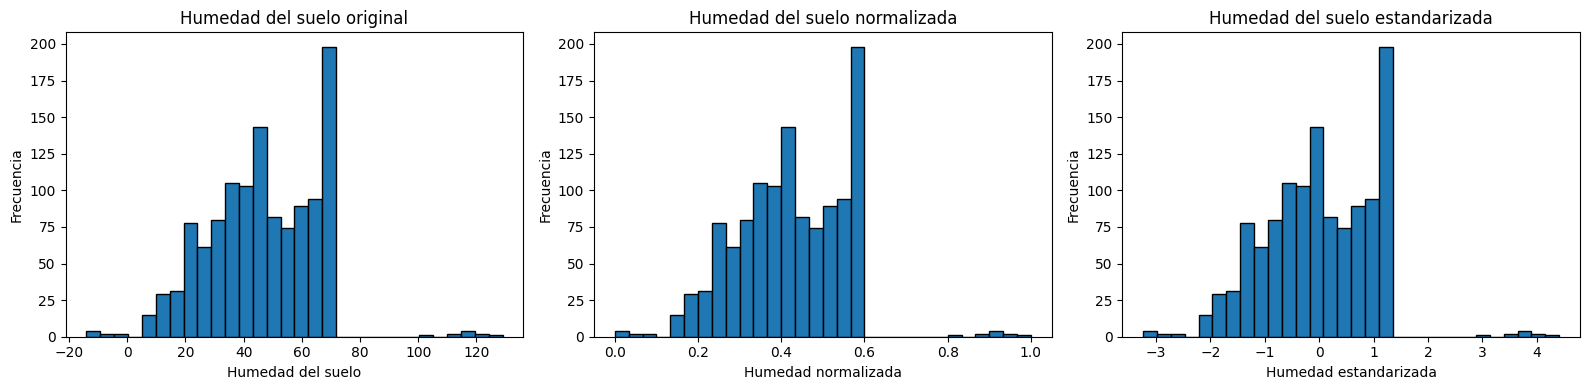

In [41]:
#histograms de comparación


# Histogramas comparativos de humedad_suelo

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Datos originales
axes[0].hist(
    df_transformado["humedad_suelo"].dropna(),
    bins=30,
    edgecolor="black"
)
axes[0].set_title("Humedad del suelo original")
axes[0].set_xlabel("Humedad del suelo")
axes[0].set_ylabel("Frecuencia")

# Datos normalizados
axes[1].hist(
    df_normalizado["humedad_suelo"].dropna(),
    bins=30,
    edgecolor="black"
)
axes[1].set_title("Humedad del suelo normalizada")
axes[1].set_xlabel("Humedad normalizada")
axes[1].set_ylabel("Frecuencia")

# Datos estandarizados
axes[2].hist(
    df_estandarizado["humedad_suelo"].dropna(),
    bins=30,
    edgecolor="black"
)
axes[2].set_title("Humedad del suelo estandarizada")
axes[2].set_xlabel("Humedad estandarizada")
axes[2].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()


Al comparar los histogramas de humedad_suelo antes y después de las transformaciones, se observa que ambas conservan prácticamente la misma forma de la distribución original. La normalización transforma los valores al intervalo [0, 1], mientras que la estandarización los expresa en función de la media y la desviación estándar.

En ambos casos, los valores atípicos siguen presentes, por lo que ninguna de las dos transformaciones los elimina ni reduce necesariamente su influencia. A partir únicamente de los histogramas, no se puede concluir que una transformación sea claramente superior a la otra.

### Ejercicio 5


In [42]:

print("Dimensiones del conjunto de datos:", df_transformado.shape)

print("\nColumnas finales:")
for columna in df_transformado.columns:
    print("-", columna)

print("\nPrimeras cinco filas:")
display(df_transformado.head())

print("\nValores ausentes por columna:")
print(df_transformado.isnull().sum())


Dimensiones del conjunto de datos: (1200, 14)

Columnas finales:
- parcela_id
- fecha
- region
- tamano_parcela
- humedad_suelo
- temperatura_C
- humedad_relativa
- luminosidad
- ph_suelo
- riego_recomendado
- tipo_cultivo_maiz
- tipo_cultivo_olivo
- tipo_cultivo_trigo
- tipo_cultivo_vid

Primeras cinco filas:


,parcela_id,fecha,region,tamano_parcela,humedad_suelo,temperatura_C,humedad_relativa,luminosidad,ph_suelo,riego_recomendado,tipo_cultivo_maiz,tipo_cultivo_olivo,tipo_cultivo_trigo,tipo_cultivo_vid
0,P040,2025-06-09,Este,1,28.16,25.92,48.19,23168.1,6.5,medio,0,0,0,1
1,P029,2025-06-26,Centro,2,68.52,16.76,58.84,17529.5,6.5,bajo,1,0,0,0
2,P004,2025-06-12,Centro,1,70.00,26.79,48.08,21869.0,6.5,bajo,0,1,0,0
3,P015,2025-06-20,Centro,1,59.72,14.95,68.29,17132.4,6.5,bajo,0,0,1,0
4,P002,2025-06-29,Sur,0,46.39,20.69,54.08,19730.3,6.5,bajo,0,0,1,0



Valores ausentes por columna:
parcela_id            0
fecha                 0
region                0
tamano_parcela        0
humedad_suelo         0
temperatura_C         0
humedad_relativa      0
luminosidad           0
ph_suelo              0
riego_recomendado     0
tipo_cultivo_maiz     0
tipo_cultivo_olivo    0
tipo_cultivo_trigo    0
tipo_cultivo_vid      0
dtype: int64


Tras el preprocesamiento y la transformación de los atributos, el conjunto de datos está más preparado para su utilización en un futuro sistema de recomendación de riego. Se han eliminado mes, por ser redundante con la fecha en este conjunto de datos, y temperatura_F, por proporcionar información redundante respecto a temperatura_C. Además, se ha aplicado One-Hot Encoding a tipo_cultivo y una codificación ordinal a tamano_parcela.

De cara a una futura recomendación de riego, consideramos especialmente relevantes humedad_suelo, por su relación directa con la disponibilidad de agua para el cultivo; temperatura_C y humedad_relativa, por aportar información sobre las condiciones ambientales; y luminosidad, por describir la exposición a la luz. También se conserva ph_suelo, aunque su baja varianza indica que presenta poca variabilidad en las observaciones disponibles. Las variables tipo_cultivo, tamano_parcela y region pueden aportar contexto adicional para adaptar la recomendación a las características de cada parcela.

Estas conclusiones se basan en el significado de los atributos y en el análisis exploratorio realizado. Para determinar cuáles son realmente los más predictivos, sería necesario entrenar y evaluar un modelo utilizando riego_recomendado como variable objetivo.